Calculo el solapamiento entre el patrón inicial y las configuraciones generadas a partir de una configuración inicial aleatoria y deformada.

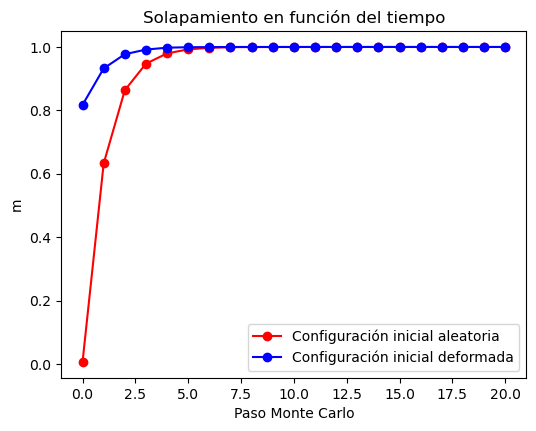

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Cargo las configuraciones de las neuronas desde el archivo generado
Matriz_neuronas_inicial_aleatoria = np.loadtxt('configuracion_inicial_neuronas_aleatoria.txt')
Matriz_neuronas_inicial_deformada = np.loadtxt('configuracion_inicial_neuronas_deformada.txt')

# Modifico la forma de la matriz para que sea un array de M matrices 150x150
Matriz_neuronas_inicial_aleatoria = Matriz_neuronas_inicial_aleatoria.reshape(-1, 150, 150)
Matriz_neuronas_inicial_deformada = Matriz_neuronas_inicial_deformada.reshape(-1, 150, 150)

M = Matriz_neuronas_inicial_aleatoria.shape[0]
N = Matriz_neuronas_inicial_aleatoria.shape[1]

# Cargo el patrón original
patron_original = np.loadtxt('Patron_original.txt')

# Calculo el valor de a
a = np.mean(patron_original)

# Defino la función que calcula el solapamiento
def solapamiento(patron_original, s, a, N):

    m = 0.0
    for i in range(N):
        for j in range(N):
                
            m += (patron_original[i, j] - a) * (s[i, j] - a) ;
        
    m = m / ((N * N) * a * (1 - a)) # Pongo el valor absoluto para que no influya que la imagen se ha invertido
    return m

# Calculo el solapamiento para cada configuración de las neuronas
solapamiento_configuracion_inicial_aleatoria = np.zeros(M)
solapamiento_configuracion_inicial_deformada = np.zeros(M)

for k in range(M):
    solapamiento_configuracion_inicial_aleatoria[k] = solapamiento(patron_original, Matriz_neuronas_inicial_aleatoria[k], a, N)
    solapamiento_configuracion_inicial_deformada[k] = solapamiento(patron_original, Matriz_neuronas_inicial_deformada[k], a, N)

# Creo un vector que contiene los números del 0 al M-1 para graficar el solapamiento en función del número del paso Monte Carlo
paso_Monte_Carlo = np.arange(M)

# Defino la figura donde voy a graficar
fig, ax = plt.subplots(figsize = (6, 4.5))
ax.plot(paso_Monte_Carlo, solapamiento_configuracion_inicial_aleatoria, marker = 'o', color = "red", label = "Configuración inicial aleatoria")
ax.plot(paso_Monte_Carlo, solapamiento_configuracion_inicial_deformada, marker = 'o', color = "blue", label = "Configuración inicial deformada")
ax.set_title("Solapamiento en función del tiempo")
ax.set_xlabel("Paso Monte Carlo")
ax.set_ylabel("m")
ax.legend()

fig.savefig("Solapamiento_1.png", dpi = 300)
plt.show()
